In [1]:
import pandas as pd 
import numpy as np

# Loading our Data

In [2]:
df = pd.read_csv("DateFruit_Dataset.csv")

df.isnull().sum()

AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
MeanRR           0
MeanRG           0
MeanRB           0
StdDevRR         0
StdDevRG         0
StdDevRB         0
SkewRR           0
SkewRG           0
SkewRB           0
KurtosisRR       0
KurtosisRG       0
KurtosisRB       0
EntropyRR        0
EntropyRG        0
EntropyRB        0
ALLdaub4RR       0
ALLdaub4RG       0
ALLdaub4RB       0
Class            0
dtype: int64

In [3]:
X = df.drop("Class", axis = 1)
y = df["Class"]

In [4]:
df["Class"].unique() # from here we can say that our neuron will have 7 neuron in output layer.

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [7]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Data to Tensors

In [8]:
import torch 
import torch.nn as nn

In [9]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

In [10]:
from torch.utils.data import TensorDataset, DataLoader

# Creating our Tensor Dataset from our tensor

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Loading our Tensor Dataset

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

# Defining our ANN model for classification

In [11]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        # Neural Network Architecture

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(in_features = X.shape[1], out_features = 64),
            nn.ReLU(),

            # 2nd hidden layer

            nn.Linear(in_features = 64, out_features = 64),
            nn.ReLU(),

            # Output Layer
            nn.Linear(in_features = 64, out_features = 7)
            
        )

    def forward(self, x):
        return self.model(x)

In [12]:
model = ANN()

# Loss and optimizer 

criterion = nn.CrossEntropyLoss()  # Loss function

import torch.optim as optim

optimizer = optim.Adam(model.parameters())  # Adam optimizer

# Training our model

In [13]:
epochs = 100
total_train_loss = []

for epoch in range(epochs):
    # Training model

    model.train()
    running_loss = 0.0

    for xb,yb in train_loader:

        optimizer.zero_grad()
        
        outputs = model(xb)             # forward propogation
        loss = criterion(outputs, yb)   # Loss function 
        loss.backward()                 # Backward Propogation

        optimizer.step()                # parameter updation through optimizer

        running_loss += loss.item()

    avg_train_loss = running_loss/len(train_loader)   # average loss per batch in 1 epoch.
    total_train_loss.append(avg_train_loss)

    print(f"{epoch + 1} epoch Training loss is {avg_train_loss}")

1 epoch Training loss is 1.6735754427702532
2 epoch Training loss is 1.0800755334937053
3 epoch Training loss is 0.7203183705392091
4 epoch Training loss is 0.5447526237239009
5 epoch Training loss is 0.4629930413287619
6 epoch Training loss is 0.3934515565633774
7 epoch Training loss is 0.34735768126404803
8 epoch Training loss is 0.30920856024907983
9 epoch Training loss is 0.2859454666790755
10 epoch Training loss is 0.2660989890927854
11 epoch Training loss is 0.2525114342570305
12 epoch Training loss is 0.22833235885785974
13 epoch Training loss is 0.2211870551109314
14 epoch Training loss is 0.21020210178002066
15 epoch Training loss is 0.19575861647077228
16 epoch Training loss is 0.18829806505338006
17 epoch Training loss is 0.17947673959576566
18 epoch Training loss is 0.17871115826394246
19 epoch Training loss is 0.16891477937283722
20 epoch Training loss is 0.17953876146803732
21 epoch Training loss is 0.16215558447267697
22 epoch Training loss is 0.1508362225216368
23 epoch

Text(0, 0.5, 'Loss')

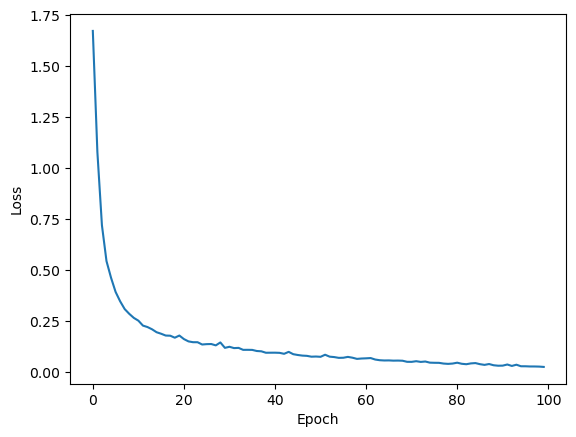

In [14]:
import matplotlib.pyplot as plt

train_df = pd.DataFrame({
    "Training Loss": total_train_loss
})

plt.plot(train_df["Training Loss"], label = "Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Evaluation

In [15]:
model.eval()
test_output = []
total = 0
correct = 0

with torch.no_grad():
    for xb,yb in test_loader:
        outputs = model(xb)
        _,predicted_val = torch.max(outputs, 1)  # it returns the maximum value and its index.
        # the index is the category predicted means if max value is at index 2 then the predicted class is 2.

        test_output.extend(predicted_val.cpu().numpy())
        correct += (predicted_val == yb).sum().item()

        total += yb.size(0)  # actual samples in each samples

print(f"Total values are {total} and Correct values are {correct}. So, accuracy is {(correct/total)*100}%")

Total values are 180 and Correct values are 168. So, accuracy is 93.33333333333333%


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, test_output))
print(classification_report(y_test, test_output))

[[11  0  0  1  0  0  0]
 [ 0 17  0  0  0  0  3]
 [ 0  4 46  0  0  0  0]
 [ 1  0  0  8  0  0  1]
 [ 0  0  0  1 34  0  0]
 [ 0  0  0  0  0 33  0]
 [ 0  1  0  0  0  0 19]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.77      0.85      0.81        20
           2       1.00      0.92      0.96        50
           3       0.80      0.80      0.80        10
           4       1.00      0.97      0.99        35
           5       1.00      1.00      1.00        33
           6       0.83      0.95      0.88        20

    accuracy                           0.93       180
   macro avg       0.90      0.92      0.91       180
weighted avg       0.94      0.93      0.93       180



In [17]:
import numpy as np

Predicted_df = pd.DataFrame(np.array(test_output).reshape(-1, 1), columns=["Predicted Output"])
Actual_df = pd.DataFrame(np.array(y_test).reshape(-1, 1), columns=["Actual Output"])

display(pd.concat([Predicted_df, Actual_df], axis=1))

,Predicted Output,Actual Output
0,2,2
1,5,5
2,2,2
3,6,6
4,0,0
...,...,...
175,5,5
176,0,0
177,1,1
178,0,0
